In [1]:
import ast
import pickle
import time
import pandas as pd
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
url = "https://api.opendota.com/api/publicMatches"
all_matches = []
params = {}
print("Pinging the OpenDota API...")

Pinging the OpenDota API...


In [3]:
response = requests.get(url)
for i in range(100):
    response = requests.get(url, params=params)

    if response.status_code == 200:
        batch_data = response.json()
        all_matches.extend(batch_data)

        oldest_match_id = min([match["match_id"] for match in batch_data])

        params = {"less_than_match_id": oldest_match_id}

        print(f"Batch {i + 1}/100 secured. Sleeping for 2 seconds...")

        time.sleep(2)

    else:
        print(
            f"Uh oh, the server got mad on batch {i + 1}. Status code: {response.status_code}"
        )
        break

Batch 1/100 secured. Sleeping for 2 seconds...
Batch 2/100 secured. Sleeping for 2 seconds...
Batch 3/100 secured. Sleeping for 2 seconds...
Batch 4/100 secured. Sleeping for 2 seconds...
Batch 5/100 secured. Sleeping for 2 seconds...
Batch 6/100 secured. Sleeping for 2 seconds...
Batch 7/100 secured. Sleeping for 2 seconds...
Batch 8/100 secured. Sleeping for 2 seconds...
Batch 9/100 secured. Sleeping for 2 seconds...
Batch 10/100 secured. Sleeping for 2 seconds...
Batch 11/100 secured. Sleeping for 2 seconds...
Batch 12/100 secured. Sleeping for 2 seconds...
Batch 13/100 secured. Sleeping for 2 seconds...
Batch 14/100 secured. Sleeping for 2 seconds...
Batch 15/100 secured. Sleeping for 2 seconds...
Batch 16/100 secured. Sleeping for 2 seconds...
Batch 17/100 secured. Sleeping for 2 seconds...
Batch 18/100 secured. Sleeping for 2 seconds...
Batch 19/100 secured. Sleeping for 2 seconds...
Batch 20/100 secured. Sleeping for 2 seconds...
Batch 21/100 secured. Sleeping for 2 seconds...
B

In [4]:
df = pd.DataFrame(all_matches)

df = df.drop_duplicates(subset="match_id")

print(f"\nHarvest complete! We collected {len(df)} unique matches.")

df.to_csv("dota_matches.csv", index=False)
print("Data safely locked away in dota_5k_matches.csv")


Harvest complete! We collected 10000 unique matches.
Data safely locked away in dota_5k_matches.csv


In [5]:
hero_data = requests.get("https://api.opendota.com/api/heroes").json()
# Create a dictionary mapping the integer ID directly to the English name
hero_dict = {hero["id"]: hero["localized_name"] for hero in hero_data}

In [6]:
print("Loading the massive dataset...")
df_match = pd.read_csv("dota_matches.csv")

Loading the massive dataset...


In [7]:
df_match["radiant_team"] = df_match["radiant_team"].apply(ast.literal_eval)
df_match["dire_team"] = df_match["dire_team"].apply(ast.literal_eval)

print(
    "Data loaded successfully! Here is what the target variable and features look like:"
)
display(
    df_match[["match_id", "radiant_win", "radiant_team", "dire_team"]].head()
)

Data loaded successfully! Here is what the target variable and features look like:


,match_id,radiant_win,radiant_team,dire_team
0,8721614834,False,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
1,8721612832,False,"[71, 50, 67, 14, 45]","[64, 49, 36, 72, 75]"
2,8721612763,False,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
3,8721611182,True,"[104, 21, 101, 30, 22]","[14, 10, 85, 25, 26]"
4,8721610021,False,"[26, 48, 29, 14, 76]","[12, 17, 63, 104, 99]"


In [8]:
print("Building the hero matrix... this might take a few seconds.")

# Add in counter features; creating a sample list of counters/synergies
counters = [
    ("Anti-Mage", "Medusa"),
    ("Earthshaker", "Meepo"),
    ("Axe", "Dazzle")
]

matrix_rows = []

for i, row in df_match.iterrows():
    # Get rid of any data with 0 for the hero_id
    if 0 in row["radiant_team"] or 0 in row["dire_team"]:
        continue

    # Create dictionary for match
    match_features = {
        "match_id": row["match_id"],
        "radiant_win": row["radiant_win"],
    }

    # +1 for Radiant hero
    for hero_id in row["radiant_team"]:
        hero_name = hero_dict.get(hero_id, f"Unknown_Hero_{hero_id}")
        match_features[hero_name] = 1

    # -1 for Dire hero
    for hero_id in row["dire_team"]:
        hero_name = hero_dict.get(hero_id, f"Unknown_Hero_{hero_id}")
        match_features[hero_name] = -1
        
    # Add interaction term for counters/synergies
    for hero_a, hero_b in counters:
        val_a = match_features.get(hero_a, 0)
        val_b = match_features.get(hero_b, 0)
        
        if val_a != 0 and val_b != 0:
            match_features[f"{hero_a}_vs_{hero_b}"] = val_a * val_b

    matrix_rows.append(match_features)

final_df = pd.DataFrame(matrix_rows).fillna(0)

print("Matrix complete! Here is the shape of our new dataset (Rows, Columns):")
print(final_df.shape)
display(final_df.head())

Building the hero matrix... this might take a few seconds.
Matrix complete! Here is the shape of our new dataset (Rows, Columns):
(9982, 132)


,match_id,radiant_win,Spirit Breaker,Dazzle,Spectre,Pudge,Pugna,Jakiro,Dragon Knight,Necrophos,...,Alchemist,Naga Siren,Dark Seer,Night Stalker,Bane,Lycan,Anti-Mage_vs_Medusa,Brewmaster,Leshrac,Earthshaker_vs_Meepo
0,8721612832,False,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8721611182,True,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,8721610021,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8721609183,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8721608566,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
X = final_df.drop(columns=["match_id", "radiant_win"])
y = final_df["radiant_win"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

print("Data successfully split!")
print(f"Training matches: {X_train.shape[0]}")
print(f"Testing matches: {X_test.shape[0]}")

Data successfully split!
Training matches: 7985
Testing matches: 1997


In [11]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

preds = log_model.predict(X_test)

score = accuracy_score(y_test, preds)
print(f"Model Accuracy: {score * 100:.2f}%")

Model Accuracy: 56.58%


In [12]:
coefficients = pd.DataFrame(
    {"Hero": X_train.columns, "Weight": log_model.coef_[0]}
)

print("Top 5 Heroes the model thinks are strong(Highest Positive Weights):")
display(coefficients.sort_values(by="Weight", ascending=False).head(5))

print("\nTop 5 Heroes the model thinks are weak (Lowest Negative Weights):")
display(coefficients.sort_values(by="Weight", ascending=True).head(5))

Top 5 Heroes the model thinks are strong(Highest Positive Weights):


,Hero,Weight
78,Vengeful Spirit,0.433185
1,Dazzle,0.428475
93,Broodmother,0.299333
50,Chaos Knight,0.283537
29,Meepo,0.242218



Top 5 Heroes the model thinks are weak (Lowest Negative Weights):


,Hero,Weight
96,Nature's Prophet,-0.351461
84,Terrorblade,-0.328065
102,Ember Spirit,-0.286878
118,Lone Druid,-0.284898
92,Queen of Pain,-0.278236


In [13]:
print("Planting the Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=12, n_jobs=-1)

print("Training the trees ...")
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_score = accuracy_score(y_test, rf_predictions)

print("\n--- FINAL RESULTS ---")
print(f"New Random Forest Accuracy: {rf_score * 100:.2f}%")

importances = pd.DataFrame(
    {"Hero": X_train.columns, "Importance": rf_model.feature_importances_}
)

print(
    "\nTop 5 Most Decisive Heroes (The ones swinging the win probability the most):"
)
display(importances.sort_values(by="Importance", ascending=False).head(5))

Planting the Random Forest...
Training the trees ...

--- FINAL RESULTS ---
New Random Forest Accuracy: 52.78%

Top 5 Most Decisive Heroes (The ones swinging the win probability the most):


,Hero,Importance
3,Pudge,0.015560
56,Sniper,0.014971
18,Lion,0.014449
47,Invoker,0.014294
13,Witch Doctor,0.013878


In [14]:
def predict_draft(radiant_team, dire_team, trained_model, template_columns):
    draft_matrix = {hero: 0 for hero in template_columns}

    for hero in radiant_team:
        if hero in draft_matrix:
            draft_matrix[hero] = 1

    for hero in dire_team:
        if hero in draft_matrix:
            draft_matrix[hero] = -1

    single_match_df = pd.DataFrame([draft_matrix])

    win_probability = trained_model.predict_proba(single_match_df)[0][1]

    print("Match Prediction")
    print(f"Radiant Draft: {', '.join(radiant_team)}")
    print(f"Dire Draft:    {', '.join(dire_team)}")

    print(f"Radiant Win Probability: {win_probability * 100:.2f}%")

    if win_probability > 0.5:
        print("Verdict: The model favors Radiant.")
    else:
        print("Verdict: The model favors Dire.")


my_radiant = [
    "Anti-Mage",
    "Crystal Maiden",
    "Earthshaker",
    "Puck",
    "Tidehunter",
]
my_dire = ["Axe", "Lion", "Phantom Assassin", "Invoker", "Pudge"]

predict_draft(my_radiant, my_dire, rf_model, X_train.columns)

Match Prediction
Radiant Draft: Anti-Mage, Crystal Maiden, Earthshaker, Puck, Tidehunter
Dire Draft:    Axe, Lion, Phantom Assassin, Invoker, Pudge
Radiant Win Probability: 42.00%
Verdict: The model favors Dire.


In [15]:
with open("dota_rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print(
    "Model successfully pickled! Your Dota 2 Oracle is now saved to dota_rf_model.pkl"
)

Model successfully pickled! Your Dota 2 Oracle is now saved to dota_rf_model.pkl


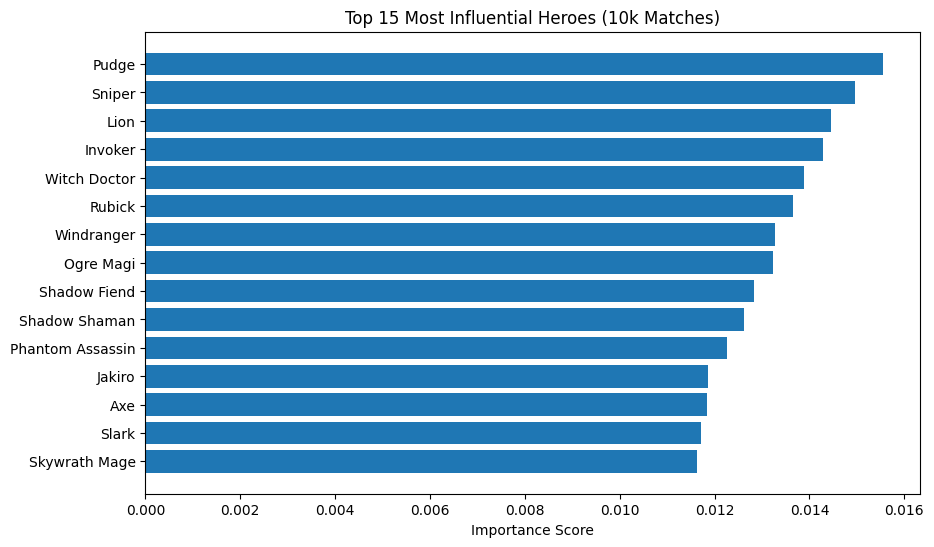

In [16]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'hero': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['hero'].head(15), feature_importance_df['importance'].head(15))
plt.xlabel("Importance Score")
plt.title("Top 15 Most Influential Heroes (10k Matches)")
plt.gca().invert_yaxis()
plt.show()

In [17]:
#Print hero names for app
hero_names_list = list(hero_dict.values())

pd.DataFrame({"Hero Name": hero_names_list}).to_csv("dota_heroes.csv", index=False)